# Assignemt 1 Characterising an AMOC timeseries

Author: Hengxi Yang

Date: Sep 2026

## Data and series

· Dataset: Denmark Strait Overflow, DSO, hourly

· Series: Overflow time-series through Denmark Strait

· Timespan: 1996-05-01 to 2021-08-07

· Record length: 221514


In [1]:
%load_ext autoreload
%autoreload 2 

In [2]:
import sys
from pathlib import Path

root_dir = Path.cwd().resolve().parent
if str(root_dir) not in sys.path:
    sys.path.append(str(root_dir))



In [ ]:
import numpy as np
import scipy.signal as signal

from amocatlas import read
from amoc_analysis.analysis import report_dataset_info
from amoc_analysis.analysis import compute_transport_stats
from amoc_analysis.plotting import plot_transport_distribution
from amoc_analysis.analysis import calculate_welch_psd
from amoc_analysis.plotting import plot_welch_psd
from amoc_analysis.analysis import verify_with_parseval
from amoc_analysis.analysis import apply_tukey_lowpass_filter, calculate_welch_psd
from amoc_analysis.plotting import plot_filtered_comparison, plot_psd_comparison
from amoc_analysis.plotting import plot_filter_frequency_responses
from amoc_analysis.analysis import compute_confidence_interval
from amoc_analysis.plotting import plot_psd_with_confidence_interval

## Part A Characterise the Series

Load dataset

In [4]:

ds_dso = read.dso()

# 1-D array
series_dso = ds_dso['TRANS_DSO'].isel(DEPTH=0)

# report info
report_dataset_info(series_dso, var_name="TRANS_DSO")

Loading 1 Denmark Strait Overflow dataset(s):
  0. DSO_transport_hourly_1996_2021.nc: Overflow time-series through Denmark Strait

********************
Record length is 221514 time steps
Timespan is from 1996-05-01 to 2021-08-07
Sampling Interval is Approximately 1 hours
18456 Missing values


Use linear interpolation to fill the NaN position

In [5]:
# linear interpolation
series_clean = series_dso.interpolate_na(dim="TIME", method="linear")

# drop the remaining NaNs at both ends
series_clean = series_clean.dropna(dim="TIME")

# report again
report_dataset_info(series_clean, var_name="TRANS_DSO")

********************
Record length is 220956 time steps
Timespan is from 1996-05-24 to 2021-08-07
Sampling Interval is Approximately 1 hours
0 Missing values


Interpret the mean, standard deviation and range.

Mean: -3.125 Sv
Standard Deviation: 1.457 Sv
Minimum: -9.661 Sv
Maximum: 3.084 Sv
Range: 12.745 Sv


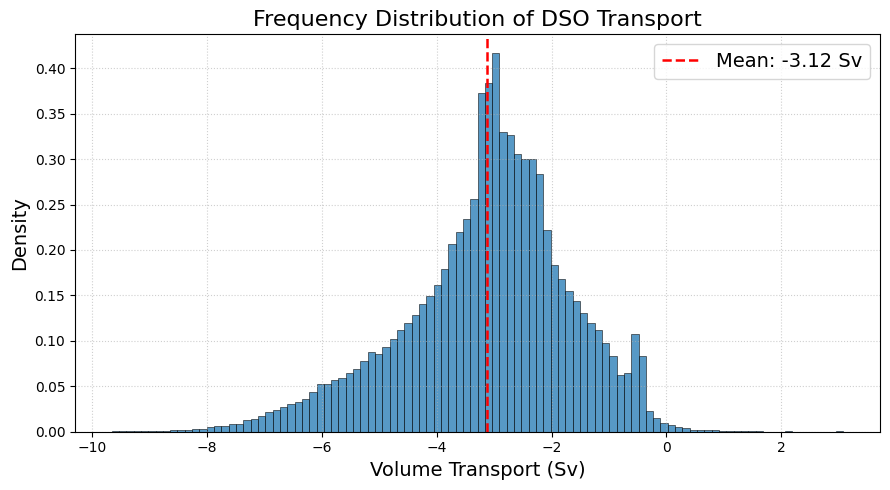

In [6]:
# compute
stats = compute_transport_stats(series_clean, var_name="TRANS_DSO")

# plot
plot_transport_distribution(series_clean, mean_val=stats["mean"], var_name="DSO")

## Part B The Spectrum

### 1.& 2. Welch's Power Spectrum

Segmenting——Windowing——Periodogram——Averaging

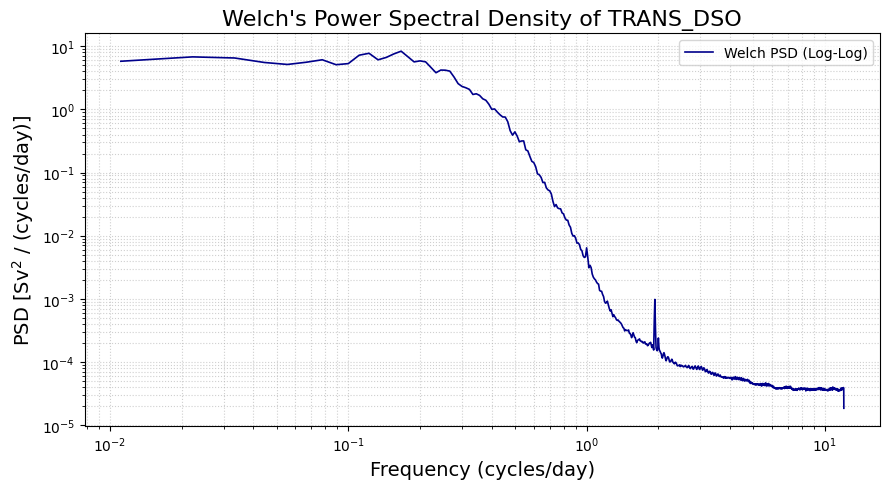

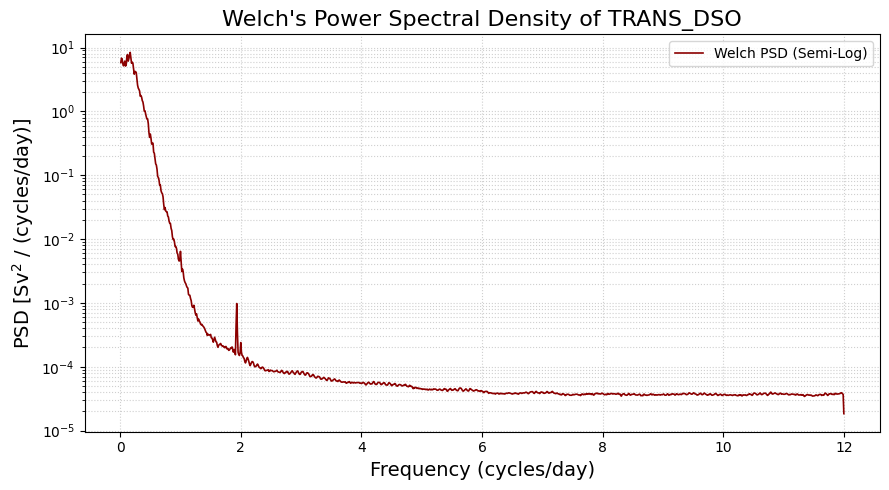

In [7]:
# compute
freqs, psd = calculate_welch_psd(series_clean, fs=24.0) # hourly sampling

# plot log-log 
plot_welch_psd(freqs, psd, var_name="TRANS_DSO", scale_type="log-log")

# plot semi-log
plot_welch_psd(freqs, psd, var_name="TRANS_DSO", scale_type="semilog")

### 3.  Verify the variance budget with Parseval's Theorem

$$\text{Variance}_{\text{time}} \approx \sum \text{PSD} \times \Delta f$$

In [8]:
results = verify_with_parseval(series_clean, freqs, psd, tolerance=0.10)

Time-domain Variance is 2.122388 Sv²
Frequency-domain Integral (PSD) is 1.931553 Sv²
Difference is 0.191
Relative Error is 8.992%
✅ Test Passed: Parseval's theorem verified successfully!


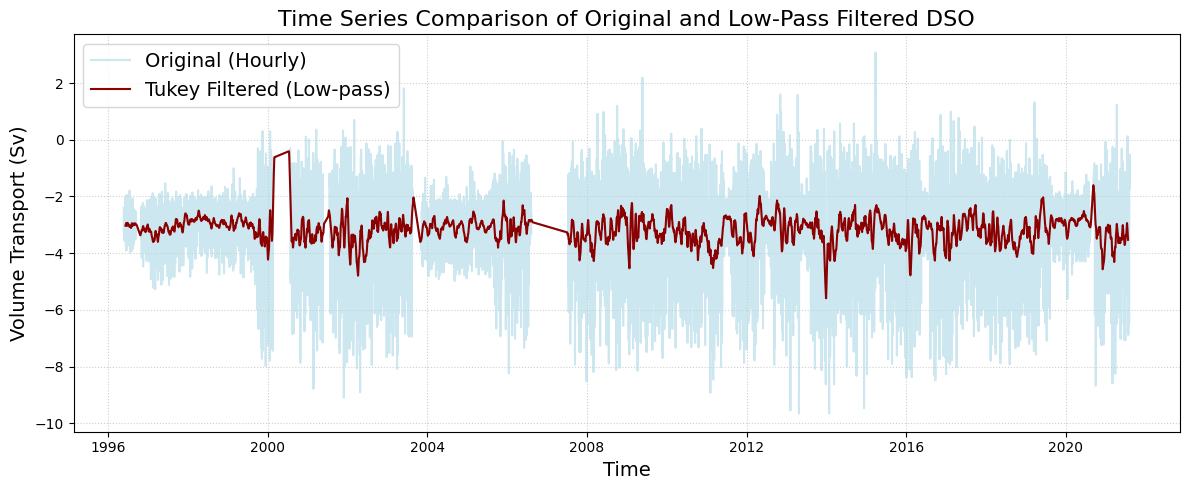

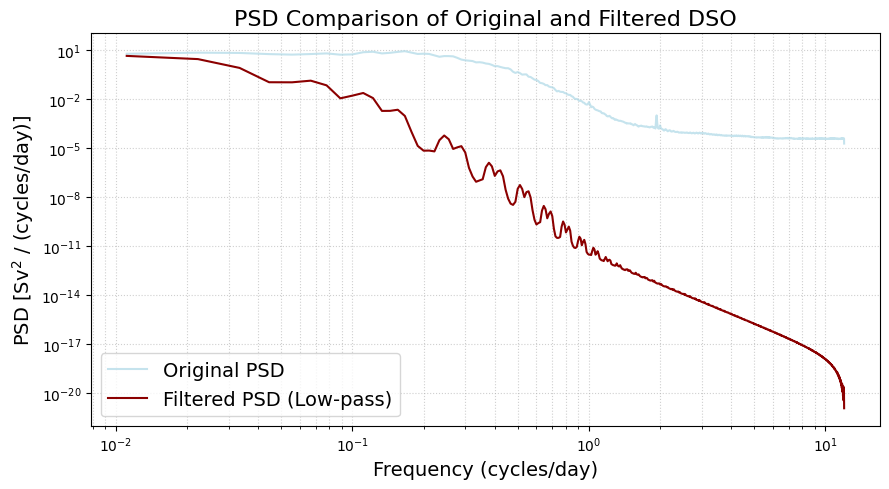

In [10]:
# Apply Turkey low-pass window
window_size = 24 * 30 # 30days
series_filtered = apply_tukey_lowpass_filter(series_clean, window_size=window_size, alpha=0.5)

# compute Welch's power spectrum
freqs_filt, psd_filt = calculate_welch_psd(series_filtered, fs=24.0)

# Timeseries comparison
plot_filtered_comparison(series_clean, series_filtered, var_name="DSO")

# PSD comparison
plot_psd_comparison(freqs, psd, freqs_filt, psd_filt, var_name="DSO")

## Part 3 Filter Design and Spectral Confidence Interval


In [ ]:
# Generate window coefficients for Tukey and Boxcar (rectangular)
window_size = 24 * 30
window_tukey = signal.windows.tukey(window_size, alpha=0.5)
window_boxcar = signal.windows.boxcar(window_size)

# Normalize weights so the DC gain is exactly 1 (0 dB)
window_tukey /= window_tukey.sum()
window_boxcar /= window_boxcar.sum()

# Compute frequency responses using scipy.signal.freqz
w_tuk, h_tuk = signal.freqz(window_tukey, worN=512)
_, h_box = signal.freqz(window_boxcar, worN=512)

# Convert digital frequency to physical frequency (cycles/day, fs = 24.0)
freqs_resp = (w_tuk / np.pi) * (24.0 / 2.0)

# Convert magnitudes to decibels (dB)
tukey_db = 20 * np.log10(np.maximum(np.abs(h_tuk), 1e-5))
boxcar_db = 20 * np.log10(np.maximum(np.abs(h_box), 1e-5))

# Plot and compare the frequency responses
plot_filter_frequency_responses(freqs_resp, tukey_db, boxcar_db)
